In [1]:
import pandas as pd

In [11]:
df=pd.read_csv("novagen_dataset.csv")


### EDA

In [12]:
df.head()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,False,True,True,False,False
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,False,False,True,False,False
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,True,False,False,False,False
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,True,False,False,True,False
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,False,True,False,True,False


In [3]:
df.shape

(9549, 23)

In [5]:
df.columns

Index(['Age', 'BMI', 'Blood_Pressure', 'Cholesterol', 'Glucose_Level',
       'Heart_Rate', 'Sleep_Hours', 'Exercise_Hours', 'Water_Intake',
       'Stress_Level', 'Target', 'Smoking', 'Alcohol', 'Diet', 'MentalHealth',
       'PhysicalActivity', 'MedicalHistory', 'Allergies', 'Diet_Type__Vegan',
       'Diet_Type__Vegetarian', 'Blood_Group_AB', 'Blood_Group_B',
       'Blood_Group_O'],
      dtype='object')

In [7]:
df.isnull().sum()

Age                      0
BMI                      0
Blood_Pressure           0
Cholesterol              0
Glucose_Level            0
Heart_Rate               0
Sleep_Hours              0
Exercise_Hours           0
Water_Intake             0
Stress_Level             0
Target                   0
Smoking                  0
Alcohol                  0
Diet                     0
MentalHealth             0
PhysicalActivity         0
MedicalHistory           0
Allergies                0
Diet_Type__Vegan         0
Diet_Type__Vegetarian    0
Blood_Group_AB           0
Blood_Group_B            0
Blood_Group_O            0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [14]:
# encoding
bool_cols = df.select_dtypes(include="bool").columns
print(bool_cols)
df[bool_cols] = df[bool_cols].astype(int)

Index(['Diet_Type__Vegan', 'Diet_Type__Vegetarian', 'Blood_Group_AB',
       'Blood_Group_B', 'Blood_Group_O'],
      dtype='object')


In [18]:
print(df[bool_cols].dtypes)
print(df[bool_cols].head())

Diet_Type__Vegan         int64
Diet_Type__Vegetarian    int64
Blood_Group_AB           int64
Blood_Group_B            int64
Blood_Group_O            int64
dtype: object
   Diet_Type__Vegan  Diet_Type__Vegetarian  Blood_Group_AB  Blood_Group_B  \
0                 0                      1               1              0   
1                 0                      0               1              0   
2                 1                      0               0              0   
3                 1                      0               0              1   
4                 0                      1               0              1   

   Blood_Group_O  
0              0  
1              0  
2              0  
3              0  
4              0  


In [19]:
categorical_cols = [
    "Smoking",
    "Alcohol",
    "Diet",
    "MentalHealth",
    "PhysicalActivity",
    "MedicalHistory",
    "Allergies"
]

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())


Smoking
Smoking
0    3221
1    3198
2    3130
Name: count, dtype: int64

Alcohol
Alcohol
0    3207
1    3181
2    3161
Name: count, dtype: int64

Diet
Diet
0    3150
1    3193
2    3206
Name: count, dtype: int64

MentalHealth
MentalHealth
0    3232
1    3100
2    3217
Name: count, dtype: int64

PhysicalActivity
PhysicalActivity
0    3107
1    3303
2    3139
Name: count, dtype: int64

MedicalHistory
MedicalHistory
0    3137
1    3230
2    3182
Name: count, dtype: int64

Allergies
Allergies
0    3228
1    3195
2    3126
Name: count, dtype: int64


In [20]:
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(normalize=True).sort_index())


Smoking:
Smoking
0    0.337313
1    0.334904
2    0.327783
Name: proportion, dtype: float64

Alcohol:
Alcohol
0    0.335847
1    0.333124
2    0.331029
Name: proportion, dtype: float64

Diet:
Diet
0    0.329877
1    0.334381
2    0.335742
Name: proportion, dtype: float64

MentalHealth:
MentalHealth
0    0.338465
1    0.324641
2    0.336894
Name: proportion, dtype: float64

PhysicalActivity:
PhysicalActivity
0    0.325374
1    0.345900
2    0.328726
Name: proportion, dtype: float64

MedicalHistory:
MedicalHistory
0    0.328516
1    0.338255
2    0.333229
Name: proportion, dtype: float64

Allergies:
Allergies
0    0.338046
1    0.334590
2    0.327364
Name: proportion, dtype: float64


In [21]:
print(df["Target"].value_counts())
print(df["Target"].value_counts(normalize=True))

Target
1    4979
0    4570
Name: count, dtype: int64
Target
1    0.521416
0    0.478584
Name: proportion, dtype: float64


In [22]:
# Numerical columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

print(numeric_cols)

Index(['Age', 'BMI', 'Blood_Pressure', 'Cholesterol', 'Glucose_Level',
       'Heart_Rate', 'Sleep_Hours', 'Exercise_Hours', 'Water_Intake',
       'Stress_Level', 'Target', 'Smoking', 'Alcohol', 'Diet', 'MentalHealth',
       'PhysicalActivity', 'MedicalHistory', 'Allergies', 'Diet_Type__Vegan',
       'Diet_Type__Vegetarian', 'Blood_Group_AB', 'Blood_Group_B',
       'Blood_Group_O'],
      dtype='object')


In [23]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,9549.0,33.806786,24.566473,0.0,14.0,29.0,50.0,100.0
BMI,9549.0,25.660697,1.942369,19.0,24.0,26.0,27.0,32.0
Blood_Pressure,9549.0,130.382658,27.878476,22.0,113.0,134.0,150.0,225.0
Cholesterol,9549.0,199.091528,1.969234,192.0,198.0,199.0,200.0,207.0
Glucose_Level,9549.0,100.225678,2.157999,93.0,99.0,100.0,102.0,107.0
Heart_Rate,9549.0,73.613782,1.681538,67.0,73.0,74.0,75.0,80.0
Sleep_Hours,9549.0,6.951409,2.352152,0.0,5.0,7.0,9.0,14.0
Exercise_Hours,9549.0,1.892345,1.378714,-0.0,1.0,2.0,3.0,8.0
Water_Intake,9549.0,3.580899,1.622874,-0.0,2.0,4.0,5.0,10.0
Stress_Level,9549.0,4.382134,2.078593,0.0,3.0,4.0,6.0,12.0


In [24]:
for col in numeric_cols:
    print(f"{col}: min={df[col].min()}, max={df[col].max()}")

Age: min=0.0, max=100.0
BMI: min=19.0, max=32.0
Blood_Pressure: min=22.0, max=225.0
Cholesterol: min=192.0, max=207.0
Glucose_Level: min=93.0, max=107.0
Heart_Rate: min=67.0, max=80.0
Sleep_Hours: min=0.0, max=14.0
Exercise_Hours: min=-0.0, max=8.0
Water_Intake: min=-0.0, max=10.0
Stress_Level: min=0.0, max=12.0
Target: min=0, max=1
Smoking: min=0, max=2
Alcohol: min=0, max=2
Diet: min=0, max=2
MentalHealth: min=0, max=2
PhysicalActivity: min=0, max=2
MedicalHistory: min=0, max=2
Allergies: min=0, max=2
Diet_Type__Vegan: min=0, max=1
Diet_Type__Vegetarian: min=0, max=1
Blood_Group_AB: min=0, max=1
Blood_Group_B: min=0, max=1
Blood_Group_O: min=0, max=1


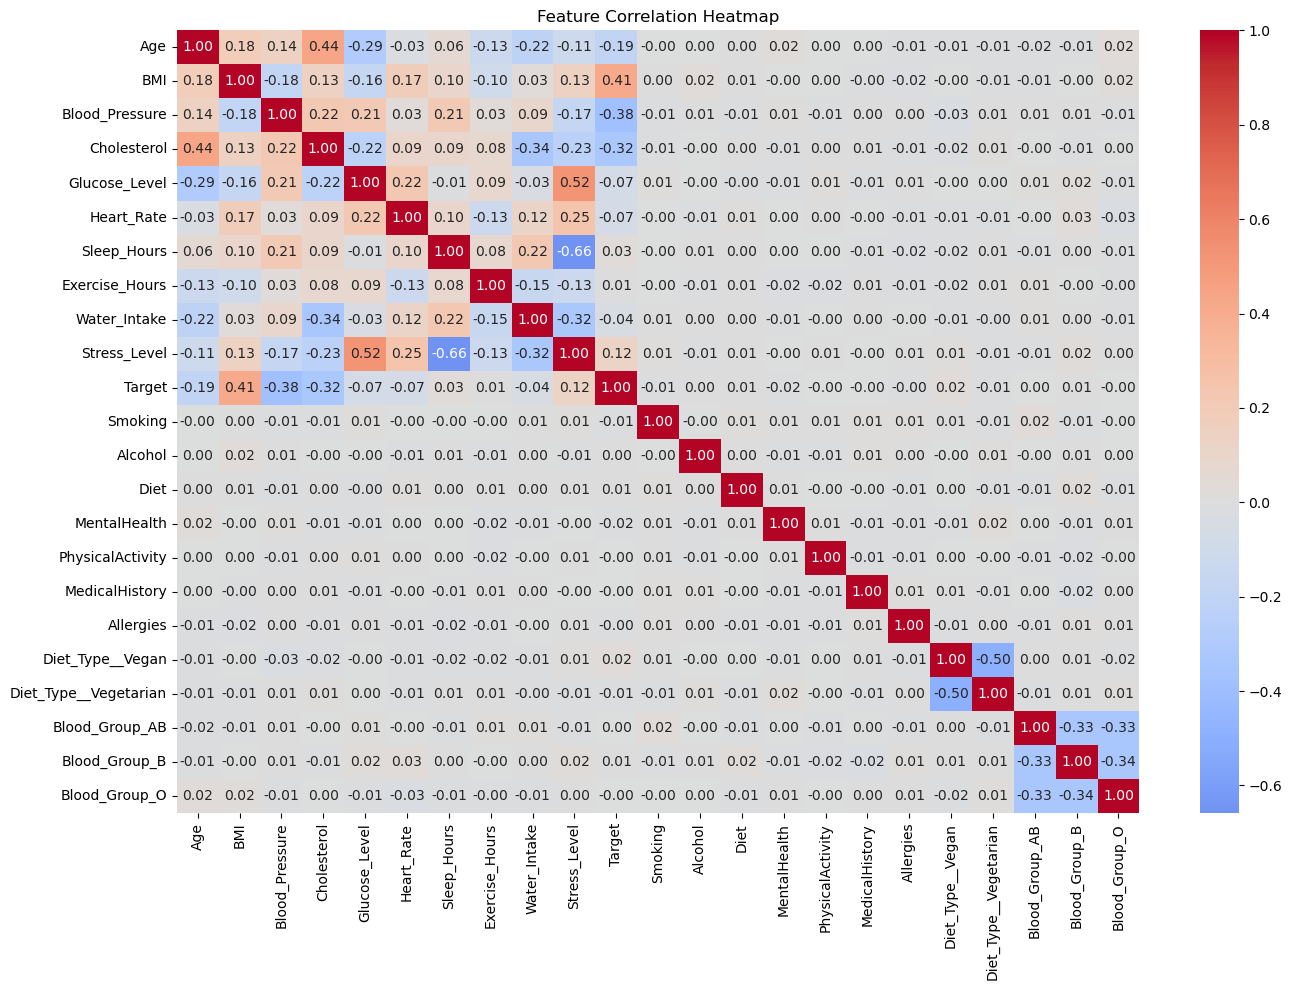

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlations
correlation = df.corr(numeric_only=True)

# Plot correlation heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [28]:
X = df.drop("Target", axis=1)
y = df["Target"]

print(X.shape)
print(y.shape)

(9549, 22)
(9549,)


### Train test split

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training: (7639, 22)
Testing : (1910, 22)

Training target distribution:
Target
1    0.521403
0    0.478597
Name: proportion, dtype: float64

Testing target distribution:
Target
1    0.521466
0    0.478534
Name: proportion, dtype: float64


### Logistic regression

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [31]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42))
])

In [36]:
logistic_model.fit(X_train, y_train)
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.8136125654450261
Precision: 0.8174603174603174
Recall   : 0.8273092369477911
F1 Score : 0.8223552894211577
ROC-AUC  : 0.8879072087035231

Confusion Matrix:
[[730 184]
 [172 824]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.80       914
           1       0.82      0.83      0.82       996

    accuracy                           0.81      1910
   macro avg       0.81      0.81      0.81      1910
weighted avg       0.81      0.81      0.81      1910



### Decision Tree

In [38]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]

In [39]:
print("Accuracy :", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall   :", recall_score(y_test, y_pred_tree))
print("F1 Score :", f1_score(y_test, y_pred_tree))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_tree))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

Accuracy : 0.8916230366492146
Precision: 0.8841285296981499
Recall   : 0.9116465863453815
F1 Score : 0.897676717745922
ROC-AUC  : 0.890724824901356

Confusion Matrix:
[[795 119]
 [ 88 908]]


### Random Forest

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [41]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy : 0.9366492146596859
Precision: 0.9259980525803311
Recall   : 0.9548192771084337
F1 Score : 0.9401878398418191
ROC-AUC  : 0.9845097018270016

Confusion Matrix:
[[838  76]
 [ 45 951]]


In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance)

BMI                      0.209153
Blood_Pressure           0.159544
Cholesterol              0.105613
Stress_Level             0.085483
Glucose_Level            0.072906
Sleep_Hours              0.070151
Age                      0.067891
Heart_Rate               0.051667
Water_Intake             0.047213
Exercise_Hours           0.026918
Smoking                  0.011041
MentalHealth             0.010963
PhysicalActivity         0.010959
MedicalHistory           0.010838
Alcohol                  0.010825
Allergies                0.010702
Diet                     0.010358
Diet_Type__Vegan         0.005761
Blood_Group_B            0.005628
Blood_Group_O            0.005566
Blood_Group_AB           0.005440
Diet_Type__Vegetarian    0.005381
dtype: float64


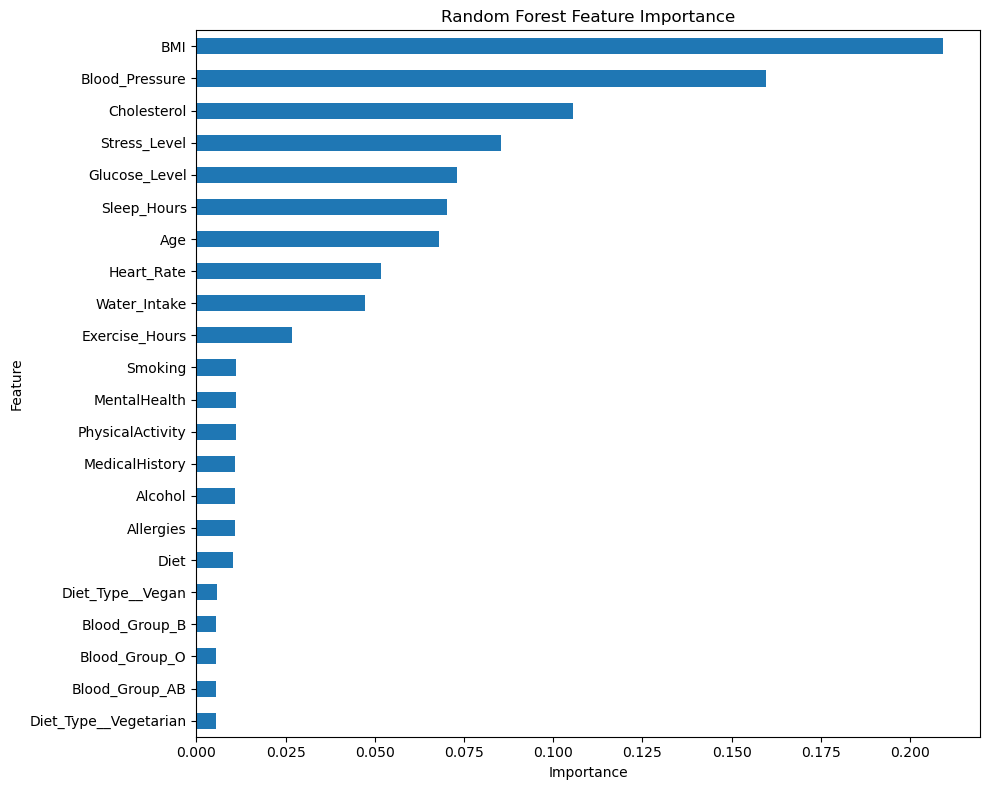

In [43]:
plt.figure(figsize=(10, 8))

feature_importance.sort_values().plot(kind="barh")

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### XGBOOST

In [44]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [45]:
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

Accuracy : 0.9518324607329843
Precision: 0.9448818897637795
Recall   : 0.963855421686747
F1 Score : 0.9542743538767395
ROC-AUC  : 0.9887976413311891

Confusion Matrix:
[[858  56]
 [ 36 960]]


In [46]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=-1
)

for metric in ["test_accuracy", "test_precision", "test_recall", "test_f1", "test_roc_auc"]:
    print(f"{metric}: {cv_results[metric].mean():.4f} ± {cv_results[metric].std():.4f}")

test_accuracy: 0.9415 ± 0.0061
test_precision: 0.9412 ± 0.0100
test_recall: 0.9470 ± 0.0028
test_f1: 0.9441 ± 0.0055
test_roc_auc: 0.9818 ± 0.0025


### Tuning

In [47]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7]
}

In [48]:
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,n_iter,30
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [49]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV ROC-AUC:")
print(random_search.best_score_)

Best Parameters:
{'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

Best CV ROC-AUC:
0.9840719604755381


In [50]:
best_xgb = random_search.best_estimator_

y_pred_best = best_xgb.predict(X_test)
y_prob_best = best_xgb.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_best))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

Accuracy : 0.956544502617801
Precision: 0.9497536945812808
Recall   : 0.9678714859437751
F1 Score : 0.9587270014917951
ROC-AUC  : 0.9897555209898676

Confusion Matrix:
[[863  51]
 [ 32 964]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       914
           1       0.95      0.97      0.96       996

    accuracy                           0.96      1910
   macro avg       0.96      0.96      0.96      1910
weighted avg       0.96      0.96      0.96      1910



In [51]:
# Feature importance from tuned XGBoost
xgb_importance = pd.Series(
    best_xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(xgb_importance)

BMI                      0.190962
Cholesterol              0.169350
Stress_Level             0.099522
Glucose_Level            0.078738
Sleep_Hours              0.069514
Blood_Pressure           0.068332
Water_Intake             0.052927
Heart_Rate               0.046135
Exercise_Hours           0.033626
Age                      0.025442
PhysicalActivity         0.014988
Allergies                0.014746
Diet                     0.013989
MentalHealth             0.013948
Blood_Group_O            0.013790
Alcohol                  0.013758
Blood_Group_AB           0.013705
MedicalHistory           0.013659
Blood_Group_B            0.013628
Diet_Type__Vegetarian    0.013598
Smoking                  0.012829
Diet_Type__Vegan         0.012815
dtype: float32


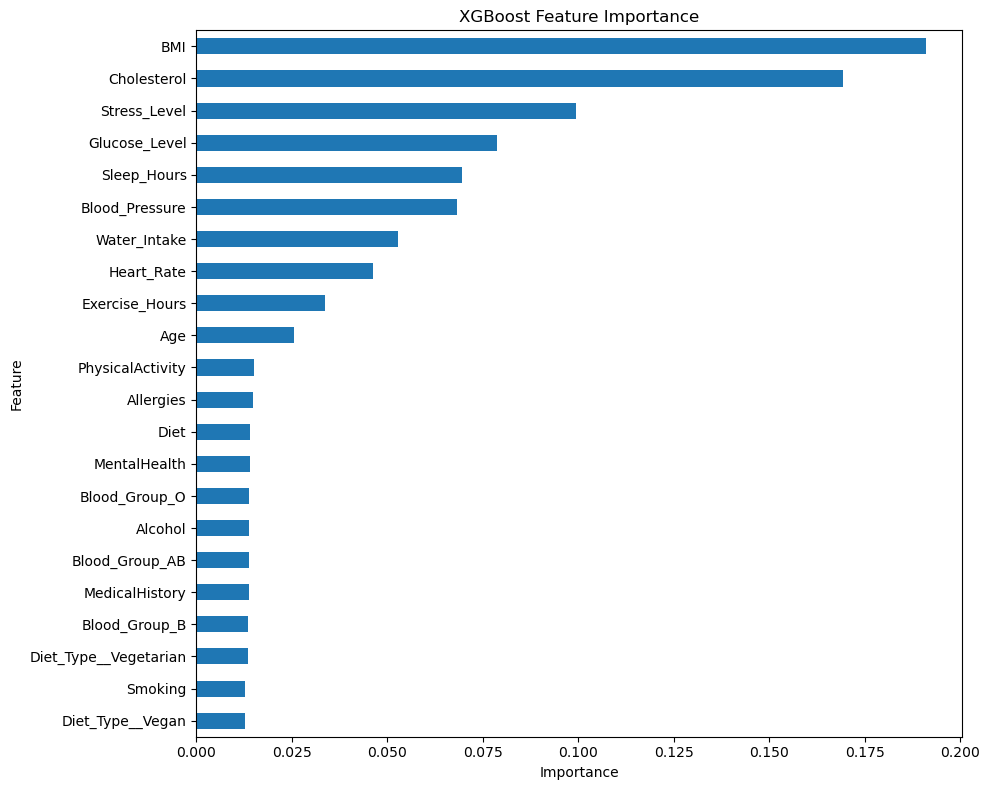

In [52]:
plt.figure(figsize=(10, 8))

xgb_importance.sort_values().plot(kind="barh")

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [53]:
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

In [54]:
importance_comparison = pd.DataFrame({
    "Random Forest": rf_importance,
    "XGBoost": xgb_importance
}).sort_values("XGBoost", ascending=False)

print(importance_comparison)

                       Random Forest   XGBoost
BMI                         0.209153  0.190962
Cholesterol                 0.105613  0.169350
Stress_Level                0.085483  0.099522
Glucose_Level               0.072906  0.078738
Sleep_Hours                 0.070151  0.069514
Blood_Pressure              0.159544  0.068332
Water_Intake                0.047213  0.052927
Heart_Rate                  0.051667  0.046135
Exercise_Hours              0.026918  0.033626
Age                         0.067891  0.025442
PhysicalActivity            0.010959  0.014988
Allergies                   0.010702  0.014746
Diet                        0.010358  0.013989
MentalHealth                0.010963  0.013948
Blood_Group_O               0.005566  0.013790
Alcohol                     0.010825  0.013758
Blood_Group_AB              0.005440  0.013705
MedicalHistory              0.010838  0.013659
Blood_Group_B               0.005628  0.013628
Diet_Type__Vegetarian       0.005381  0.013598
Smoking      

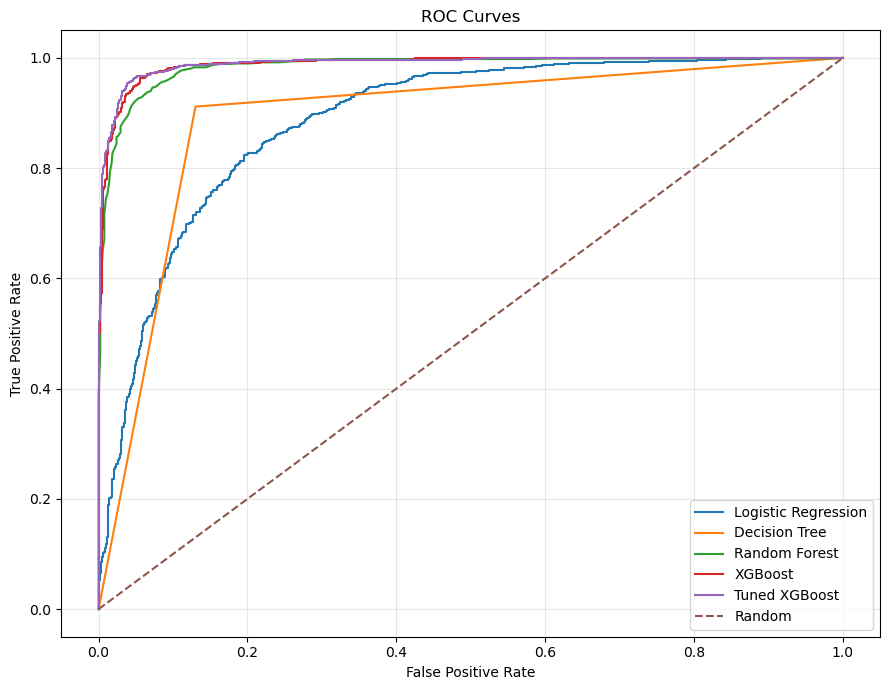

In [55]:
from sklearn.metrics import roc_curve, auc

# ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_best, tpr_best, _ = roc_curve(y_test, y_prob_best)

plt.figure(figsize=(9, 7))

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_tree, tpr_tree, label="Decision Tree")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")
plt.plot(fpr_best, tpr_best, label="Tuned XGBoost")

# Random classifier
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

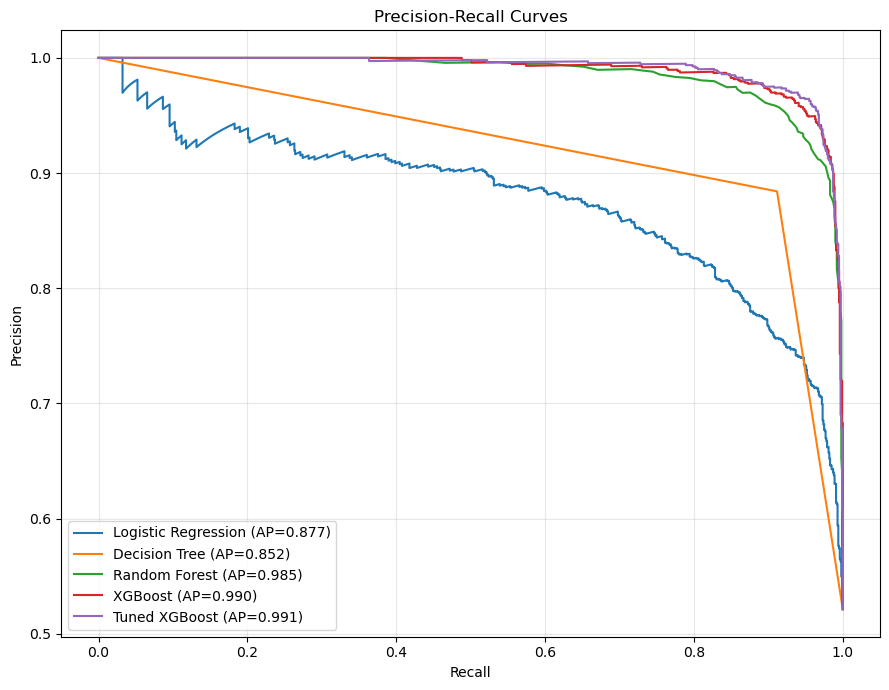

In [56]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob)
precision_tree, recall_tree, _ = precision_recall_curve(y_test, y_prob_tree)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
precision_best, recall_best, _ = precision_recall_curve(y_test, y_prob_best)

plt.figure(figsize=(9, 7))

plt.plot(
    recall_lr,
    precision_lr,
    label=f"Logistic Regression (AP={average_precision_score(y_test, y_prob):.3f})"
)

plt.plot(
    recall_tree,
    precision_tree,
    label=f"Decision Tree (AP={average_precision_score(y_test, y_prob_tree):.3f})"
)

plt.plot(
    recall_rf,
    precision_rf,
    label=f"Random Forest (AP={average_precision_score(y_test, y_prob_rf):.3f})"
)

plt.plot(
    recall_xgb,
    precision_xgb,
    label=f"XGBoost (AP={average_precision_score(y_test, y_prob_xgb):.3f})"
)

plt.plot(
    recall_best,
    precision_best,
    label=f"Tuned XGBoost (AP={average_precision_score(y_test, y_prob_best):.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [57]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Tuned XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_best)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_best)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_best)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_best)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_tree),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_best)
    ]
})

print(results.round(4))

                 Model  Accuracy  Precision  Recall      F1  ROC-AUC
0  Logistic Regression    0.8136     0.8175  0.8273  0.8224   0.8879
1        Decision Tree    0.8916     0.8841  0.9116  0.8977   0.8907
2        Random Forest    0.9366     0.9260  0.9548  0.9402   0.9845
3              XGBoost    0.9518     0.9449  0.9639  0.9543   0.9888
4        Tuned XGBoost    0.9565     0.9498  0.9679  0.9587   0.9898


In [58]:
# Predictions on training data
y_train_pred = best_xgb.predict(X_train)
y_train_prob = best_xgb.predict_proba(X_train)[:, 1]

print("TRAINING PERFORMANCE")
print("--------------------")
print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("F1 Score :", f1_score(y_train, y_train_pred))
print("ROC-AUC  :", roc_auc_score(y_train, y_train_prob))

print("\nTEST PERFORMANCE")
print("----------------")
print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_best))

TRAINING PERFORMANCE
--------------------
Accuracy : 0.9977745778243226
F1 Score : 0.9978661980670265
ROC-AUC  : 0.9999765139699303

TEST PERFORMANCE
----------------
Accuracy : 0.956544502617801
F1 Score : 0.9587270014917951
ROC-AUC  : 0.9897555209898676


In [60]:
for column in X.columns:
    print(f"\n{'=' * 50}")
    print(column)
    print(pd.crosstab(
        df[column],
        df["Target"],
        normalize="index"
    ).round(3))


Age
Target      0      1
Age                 
0.0     0.469  0.531
1.0     0.390  0.610
2.0     0.408  0.592
3.0     0.414  0.586
4.0     0.407  0.593
...       ...    ...
96.0    0.821  0.179
97.0    0.882  0.118
98.0    0.667  0.333
99.0    0.950  0.050
100.0   0.842  0.158

[101 rows x 2 columns]

BMI
Target      0      1
BMI                 
19.0    0.875  0.125
20.0    0.971  0.029
21.0    0.981  0.019
22.0    0.958  0.042
23.0    0.904  0.096
24.0    0.699  0.301
25.0    0.483  0.517
26.0    0.384  0.616
27.0    0.262  0.738
28.0    0.261  0.739
29.0    0.320  0.680
30.0    0.379  0.621
31.0    0.423  0.577
32.0    0.625  0.375

Blood_Pressure
Target            0    1
Blood_Pressure          
22.0            0.0  1.0
30.0            0.0  1.0
31.0            0.0  1.0
35.0            0.0  1.0
36.0            0.0  1.0
...             ...  ...
207.0           1.0  0.0
209.0           1.0  0.0
210.0           1.0  0.0
213.0           1.0  0.0
225.0           1.0  0.0

[175 rows x 2 c

In [61]:
important_features = [
    "BMI",
    "Blood_Pressure",
    "Cholesterol",
    "Stress_Level",
    "Glucose_Level",
    "Sleep_Hours",
    "Age",
    "Heart_Rate",
    "Water_Intake",
    "Exercise_Hours"
]

In [62]:
X_simple = df[important_features]
y = df["Target"]

X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

simple_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=1.0,
    min_child_weight=1,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

simple_xgb.fit(X_train_simple, y_train_simple)

simple_pred = simple_xgb.predict(X_test_simple)
simple_prob = simple_xgb.predict_proba(X_test_simple)[:, 1]

print("Accuracy :", accuracy_score(y_test_simple, simple_pred))
print("Precision:", precision_score(y_test_simple, simple_pred))
print("Recall   :", recall_score(y_test_simple, simple_pred))
print("F1 Score :", f1_score(y_test_simple, simple_pred))
print("ROC-AUC  :", roc_auc_score(y_test_simple, simple_prob))

Accuracy : 0.9591623036649215
Precision: 0.9535573122529645
Recall   : 0.9688755020080321
F1 Score : 0.9611553784860558
ROC-AUC  : 0.990512377738525


In [63]:
from sklearn.model_selection import cross_validate

# Full feature set
full_cv = cross_validate(
    best_xgb,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=-1
)

# Numerical-only feature set
simple_cv = cross_validate(
    simple_xgb,
    X_simple,
    y,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=-1
)

print("FULL FEATURES")
print("-------------")
for metric in ["test_accuracy", "test_precision", "test_recall",
                "test_f1", "test_roc_auc"]:
    print(f"{metric}: {full_cv[metric].mean():.4f} ± {full_cv[metric].std():.4f}")

print("\nNUMERICAL ONLY")
print("--------------")
for metric in ["test_accuracy", "test_precision", "test_recall",
                "test_f1", "test_roc_auc"]:
    print(f"{metric}: {simple_cv[metric].mean():.4f} ± {simple_cv[metric].std():.4f}")

FULL FEATURES
-------------
test_accuracy: 0.9502 ± 0.0057
test_precision: 0.9508 ± 0.0069
test_recall: 0.9538 ± 0.0051
test_f1: 0.9523 ± 0.0054
test_roc_auc: 0.9860 ± 0.0039

NUMERICAL ONLY
--------------
test_accuracy: 0.9532 ± 0.0061
test_precision: 0.9542 ± 0.0078
test_recall: 0.9562 ± 0.0060
test_f1: 0.9552 ± 0.0058
test_roc_auc: 0.9869 ± 0.0040


# Health Prediction using Machine Learning

## Objective
Build a supervised classification model to predict the binary `Target` variable using health-related features.

## Dataset
The dataset contains numerical health measurements and categorical/ordinal variables. The target distribution is reasonably balanced:

| Target | Count | Proportion |
|---|---:|---:|
| 0 | 4570 | 47.86% |
| 1 | 4979 | 52.14% |

Ordinal variables such as `Smoking`, `Alcohol`, `Diet`, `MentalHealth`, `PhysicalActivity`, `MedicalHistory`, and `Allergies` were represented using levels `0`, `1`, and `2`. Categorical variables were converted to binary indicators.

## EDA
The strongest correlations with the target were:

| Feature | Correlation |
|---|---:|
| BMI | 0.414 |
| Blood_Pressure | -0.380 |
| Cholesterol | -0.324 |
| Age | -0.191 |
| Stress_Level | 0.119 |

BMI, Blood Pressure, Cholesterol, and Stress Level showed the strongest relationships with the target.

## Model Comparison

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 81.31% | 81.75% | 82.73% | 82.24% | 0.8879 |
| Decision Tree | 89.16% | 88.41% | 91.16% | 89.77% | 0.8907 |
| Random Forest | 93.66% | 92.60% | 95.48% | 94.02% | 0.9845 |
| XGBoost | 95.18% | 94.49% | 96.39% | 95.43% | 0.9888 |
| **Tuned XGBoost** | **95.65%** | **94.98%** | **96.79%** | **95.87%** | **0.9898** |

## XGBoost Tuning

Best parameters:

`n_estimators=300`, `max_depth=8`, `learning_rate=0.05`, `subsample=0.9`, `min_child_weight=1`, `colsample_bytree=1.0`

Best CV ROC-AUC: **0.9841**

## Final Model

The tuned XGBoost model achieved:

- Accuracy: **95.65%**
- Precision: **94.98%**
- Recall: **96.79%**
- F1 Score: **95.87%**
- ROC-AUC: **0.9898**

Confusion Matrix:

`[[863, 51], [32, 964]]`

ROC-AUC measures how well the model separates the two classes across different probability thresholds. It is not the same as accuracy.

## Cross-Validation

Five-fold CV for XGBoost:

| Metric | Mean ± Std |
|---|---:|
| Accuracy | 94.15% ± 0.61% |
| Precision | 94.12% ± 1.00% |
| Recall | 94.70% ± 0.28% |
| F1 | 94.41% ± 0.55% |
| ROC-AUC | 0.9818 ± 0.0025 |

## Feature Importance

The most important predictors were:

1. BMI
2. Cholesterol
3. Stress Level
4. Glucose Level
5. Sleep Hours
6. Blood Pressure
7. Water Intake
8. Heart Rate
9. Exercise Hours
10. Age

## Feature Set Comparison

Numerical-only features slightly outperformed the complete feature set in five-fold cross-validation.

| Metric | Full Features | Numerical Only |
|---|---:|---:|
| Accuracy | 95.02% ± 0.57% | **95.32% ± 0.61%** |
| Precision | 95.08% ± 0.69% | **95.42% ± 0.78%** |
| Recall | 95.38% ± 0.51% | **95.62% ± 0.60%** |
| F1 | 95.23% ± 0.54% | **95.52% ± 0.58%** |
| ROC-AUC | 0.9860 ± 0.0039 | **0.9869 ± 0.0040** |

## Conclusion

Tuned XGBoost was the best-performing model. The results show that the numerical health measurements contain most of the predictive information in this dataset.

The model achieved strong performance, with **95.65% test accuracy and 0.9898 ROC-AUC**. However, several variables show unusually strong relationships with the target, so these results should be interpreted as performance on the supplied dataset and not as clinical diagnostic performance.
